In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from src.preprocessing.cleaner import preprocess_for_tfidf
from src.features.tfidf import TFIDFVectorizer

In [3]:
valid_df = pd.read_csv("../data/interim/valid_split.csv")

C:\Users\fam-01\AppData\Local\Temp\ipykernel_6752\1180997630.py:1: DtypeWarning: Columns (0: vote) have mixed types. Specify dtype option on import or set low_memory=False.
  valid_df = pd.read_csv("../data/interim/valid_split.csv")


In [4]:
valid_df["clean_text"] = valid_df["reviewText"].fillna("").apply(preprocess_for_tfidf)

In [5]:
tfidf = TFIDFVectorizer.load("../artifacts/vectorizers/tfidf.joblib")

In [6]:
X_valid = tfidf.transform(valid_df["clean_text"])

In [7]:
logistic = joblib.load("../artifacts/models/logistic_regression.joblib")

In [8]:
valid_df["prediction"] = logistic.predict(X_valid)

In [9]:
valid_df["correct"] = valid_df["overall"] == valid_df["prediction"]

In [10]:
valid_df["correct"].value_counts()

correct
True     118543
False     49246
Name: count, dtype: int64

In [11]:
valid_df["correct"].mean()

np.float64(0.7065004261304376)

In [12]:
errors = valid_df[valid_df["correct"] == False]

In [13]:
errors.head()

,overall,vote,verified,reviewTime,reviewerID,asin,style,reviewerName,reviewText,summary,unixReviewTime,clean_text,prediction,correct
0,1,NaN,True,2016-07-21,A2KYLWTO7DDBWN,B004PYEBZ2,{'Color:': ' Black'},A. Cline,I can have these on the charger all day and th...,Buy ones with batteries,1469059200,i can have these on the charger all day and th...,3,False
1,1,4.0,True,2016-04-14,A1PMDHXSFK5EHM,B00UA55ZRI,{'Platform:': ' PlayStation 4'},Kyle,UPDATE 10/18/2016\nSo after months with the da...,Not a good product,1460592000,update 10/18/2016 so after months with the dat...,5,False
4,4,NaN,True,2017-09-14,A1Z6ICV0CAJCFS,B00UIT28FI,NaN,APRIL Lee,Not bad. I do wish it stayed on better. The ve...,Good. Needs some adjustments.,1505347200,not bad. i do wish it stayed on better. the ve...,3,False
7,5,NaN,True,2016-05-28,A2G29U7UOI6P5N,B002CMOH26,NaN,Dmf,In general this HDD (hard disk drive) does eve...,Great starting drive for new computer or just ...,1464393600,in general this hdd (hard disk drive) does eve...,4,False
10,4,2.0,True,2016-12-10,A4W5B87I68P9T,B01230V2U6,NaN,Dale H. Cline,This is a great machine. You DO NO NEED DRIVE ...,Do not listen to seller.,1481328000,this is a great machine. you do no need drive ...,5,False


In [ ]:
errors[
    [
        "overall",
        "prediction",
        "summary",
        "reviewText",
    ]
].sample(10, random_state=42)

,overall,prediction,summary,reviewText
0,1,3,Buy ones with batteries,I can have these on the charger all day and th...
1,1,5,Not a good product,UPDATE 10/18/2016\nSo after months with the da...
4,4,3,Good. Needs some adjustments.,Not bad. I do wish it stayed on better. The ve...
7,5,4,Great starting drive for new computer or just ...,In general this HDD (hard disk drive) does eve...
10,4,5,Do not listen to seller.,This is a great machine. You DO NO NEED DRIVE ...
11,3,5,Not Pro Level Performance.,UPDATE 3/20/18\nAfter months waiting on a new ...
16,5,1,Samsung Deserves A Standing Ovation! (and I'm ...,South Korea is nothing like that abomination u...
18,4,1,Poor quality. Stitching came loose and the inn...,Poor quality. Stitching came loose and the inn...
23,5,3,My listening is focused on musical recordings ...,These headphones are certainly not the most ex...
25,4,5,"Good range, reliable, but biggish",I get this type for places where it needs a lo...


In [15]:
errors.groupby(
    [
        "overall",
        "prediction",
    ]
).size().sort_values(ascending=False)

overall  prediction
4        5             14837
5        4              5603
3        4              4046
2        1              3517
3        5              3396
2        3              2644
4        3              2491
1        2              1715
3        1              1579
2        5              1542
3        2              1471
1        5              1339
         3              1087
2        4               982
5        3               737
         1               628
4        1               577
1        4               436
4        2               396
5        2               223
dtype: int64

In [16]:
errors["review_length"] = errors["reviewText"].fillna("").str.len()

(array([4.7739e+04, 1.2380e+03, 1.8000e+02, 5.3000e+01, 2.1000e+01,
        1.1000e+01, 1.0000e+00, 2.0000e+00, 0.0000e+00, 1.0000e+00]),
 array([  200. ,  2405.8,  4611.6,  6817.4,  9023.2, 11229. , 13434.8,
        15640.6, 17846.4, 20052.2, 22258. ]),
 <BarContainer object of 10 artists>)

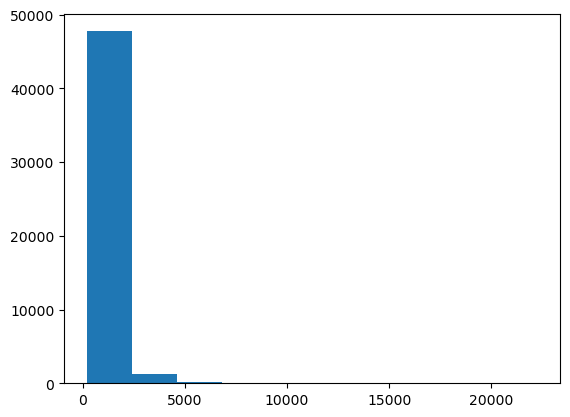

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(valid_df["review_length"], bins=50)
plt.title("All Reviews")

plt.subplot(1, 2, 2)
plt.hist(errors["review_length"], bins=50)
plt.title("Incorrect Predictions")

In [18]:
errors["overall"].value_counts().sort_index()

overall
1     4577
2     8685
3    10492
4    18301
5     7191
Name: count, dtype: int64

In [19]:
class_accuracy = valid_df.groupby("overall")["correct"].mean()

<Axes: xlabel='overall'>

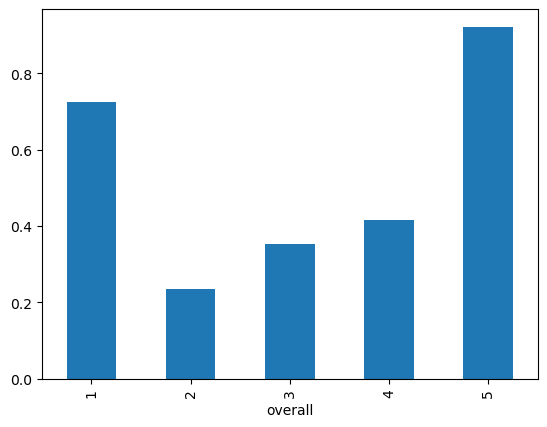

In [20]:
class_accuracy.plot.bar()

In [ ]:
for cls in [2, 3, 4]:
    display(errors[errors["overall"] == cls].sample(5, random_state=42))

,overall,vote,verified,reviewTime,reviewerID,asin,style,reviewerName,reviewText,summary,unixReviewTime,clean_text,prediction,correct,review_length
26790,2,4.0,True,2017-09-17,A37OAJOFAR4YVO,B00QSWUYF0,{'Color:': ' A-Armygreen-Large'},J. Lucas,"I had to change my rating, because when I firs...",I loved it. I use it to carry everything I ...,1505606400,"i had to change my rating, because when i firs...",1,False,395
32094,2,NaN,True,2017-04-05,A2C8YKPAF27TJB,B001CY0P7G,NaN,John,It has no disc in the package for the driver. ...,Worthless with no driver software,1491350400,it has no disc in the package for the driver. ...,1,False,234
1011,2,NaN,True,2016-03-20,A56IAIR71TPP5,B00JMK1JFY,NaN,Bilbo,"First, the antenna was coated with a silver su...",Poor excuse for an antenna,1458432000,"first, the antenna was coated with a silver su...",1,False,369
163383,2,NaN,True,2017-05-19,ADGDQL5WSMKN4,B011EG5HJ2,NaN,max,Well I got it but my phone wasn't compatible w...,good for kids I think.,1495152000,well i got it but my phone wasn't compatible w...,5,False,209
82574,2,NaN,True,2016-06-08,A3TE252WDI9D1Y,B01ALSTZM4,{'Color:': ' Black'},Forschberr,"Very cheap feeling, and could barely fit them ...","Cheap Chinese Earbuds, Very Uncomfortable",1465344000,"very cheap feeling, and could barely fit them ...",3,False,496
98597,2,NaN,True,2016-10-16,A2BU94AOZCPTVG,B00CK8ZQCW,NaN,Piano Girl,This was the filter indicated to be the right ...,It looks like a good quality filter,1476576000,this was the filter indicated to be the right ...,5,False,204
112547,2,NaN,True,2016-05-15,A1N3Y2L3Y15SN8,B00JB6HCIC,{'Size:': ' 27 Inch'},B. Purdy,Terrible monitor. I should have listened to my...,"Watch out, you get what you pay for",1463270400,terrible monitor. i should have listened to my...,1,False,907
59445,2,NaN,True,2017-12-28,A12CU2TOIEU8MK,B01ERLN180,{'Size:': ' 80 OHM'},Billy W. Plemons,If you're looking for a good pair of video edi...,Doesnt warn about the 1/4 plug...will update r...,1514419200,if you're looking for a good pair of video edi...,5,False,249
128906,2,NaN,False,2016-02-18,A30D25YPVD6MS5,B00IJXCNMI,"{'Color:': ' Black', 'Product Packaging:': ' S...",I. Gulko,"They were good earbuds for the price, and I ow...","Decent earbuds, but not reliable.",1455753600,"they were good earbuds for the price, and i ow...",3,False,373
52373,2,NaN,True,2018-02-18,A3IICSS30MRX9M,B016P9HJIA,NaN,Handsome Johnny,They are ok at replicating pre-recorded music....,They aren't really great speakers for use in a...,1518912000,they are ok at replicating pre-recorded music....,3,False,596


In [22]:
valid_df["review_length"] = valid_df["reviewText"].fillna("").str.len()

In [23]:
valid_df.groupby("correct")["review_length"].describe()

,count,mean,std,min,25%,50%,75%,max
correct,,,,,,,,
False,49246.0,678.472708,753.828659,200.0,289.0,438.0,765.0,22258.0
True,118543.0,602.422125,658.966079,200.0,273.0,397.0,668.0,21529.0


In [24]:
errors.to_csv(
    "../artifacts/error_analysis.csv",
    index=False,
)

## Findings

- Most errors occur between adjacent rating classes.
- Reviews rated 4 stars are frequently predicted as 5 stars.
- Class 2 remains the most challenging class.
- Longer reviews do not necessarily lead to better predictions.
- The baseline captures sentiment polarity well but struggles with sentiment intensity.